# Import libraries

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load full ground truth

In [8]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

In [9]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Function to generate sample charades

In [10]:
def build_sample_dataset(
    sample_gt_df,
    category_idx_fname="../data/charades/annotations/sample_category_idx.txt",
    gt_fname="../data/charades/annotations/sample_charades.json",
):  
    # Save category index to a text file
    actions = sorted(sample_gt_df["label"].unique().tolist())
    with open(category_idx_fname, "w") as f:
        for action in actions:
            f.write(action + "\n")

    # Save sample annotations to JSON file
    output = {"version": "Charades_v1_Sample", "database": {}}

    for video_id, group in sample_gt_df.groupby("video_id"):
        # keep duration/subset from the original gt
        duration = sample_gt_df[sample_gt_df["video_id"] == video_id]["duration"].iloc[0]
        subset = sample_gt_df[sample_gt_df["video_id"] == video_id]["subset"].iloc[0]

        annotations = []
        for _, row in group.iterrows():
            annotations.append(
                {"segment": [row["start"], row["end"]], "label": row["label"]}
            )
        output["database"][video_id] = {
            "duration": duration,
            "subset": subset,
            "annotations": annotations,
        }

    with open(gt_fname, "w") as f:
        json.dump(output, f, indent=2)

# Sample the 10 least common classes

In [11]:
# Select the 10 least frequent classes
least_sample_classes = sorted(
    gt_df["label"].value_counts()[-10:].index.tolist()
)

# Filter segments with classes in "10 least frequent classes"
least_common_gt = gt_df[gt_df["label"].isin(least_sample_classes)].copy()

# Build sample dataset with _category_idx.txt and _charades.json
build_sample_dataset(
    least_common_gt,
    category_idx_fname="../data/charades/annotations/least_common_category_idx.txt",
    gt_fname="../data/charades/annotations/least_common_charades.json",
)

In [12]:
print("The shape of dataset: ", least_common_gt.shape)
print("The number of unique videos: ", least_common_gt['video_id'].nunique())
least_common_gt.head()

The shape of dataset:  (449, 6)
The number of unique videos:  423


,video_id,duration,subset,start,end,label
57,A2771,30.92,training,1.2,32.0,Washing a window
70,PAS7F,30.50,testing,18.9,27.3,Throwing a box somewhere
242,DLOS7,41.42,testing,0.0,9.5,Fixing a light
416,JYG8P,30.50,training,0.0,19.3,Washing a window
572,U1BQ0,29.71,training,0.0,3.9,Throwing a box somewhere


### Explore the 10 least common classes dataset

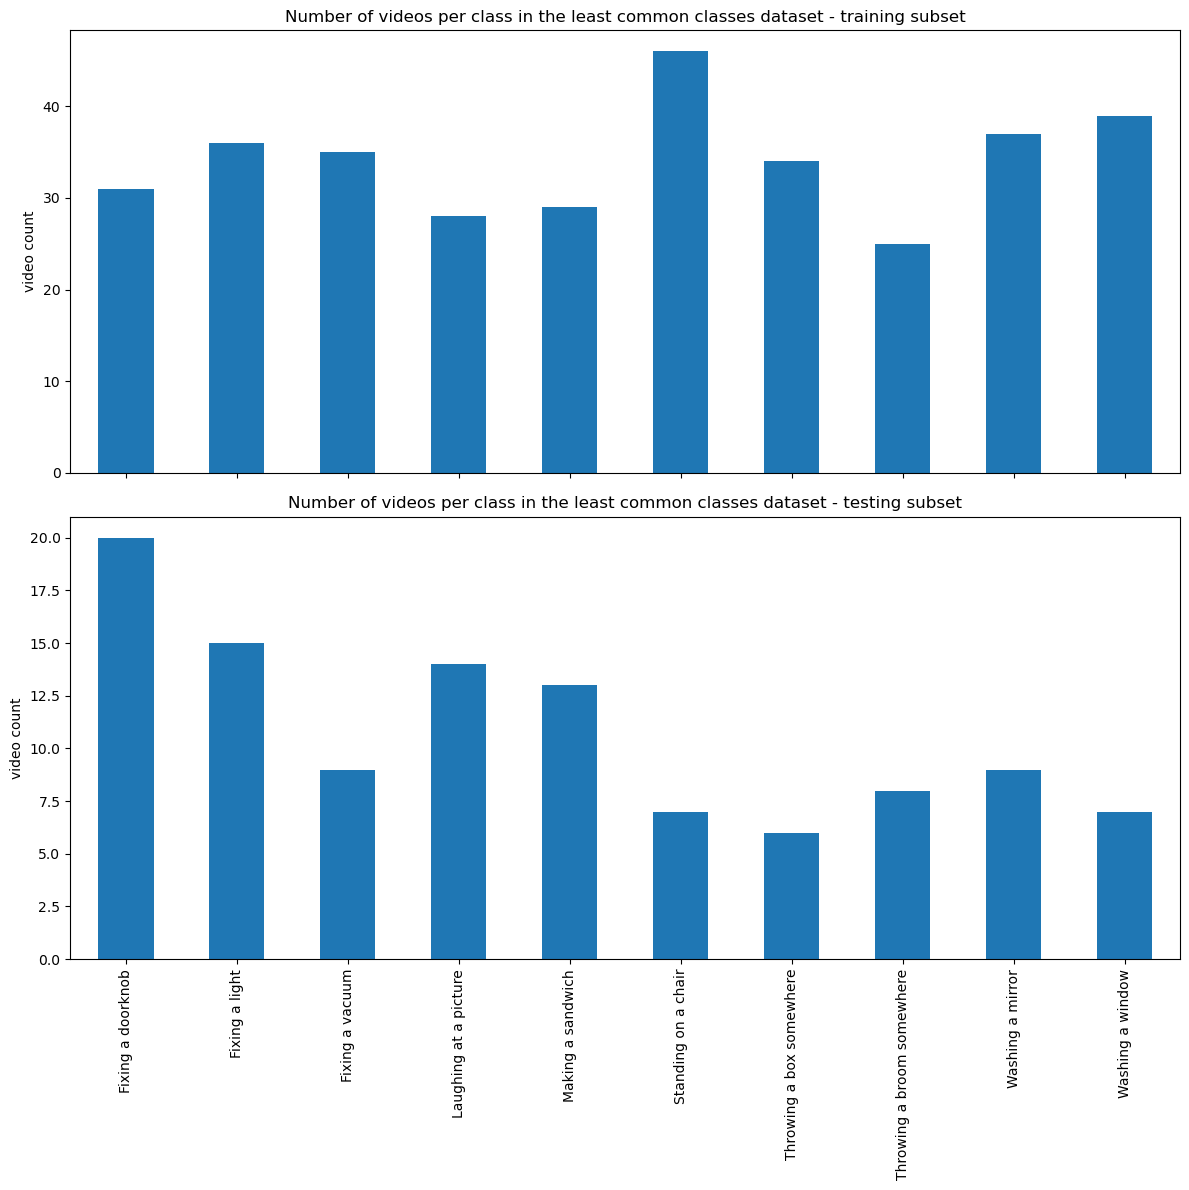

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

least_common_gt[least_common_gt["subset"] == "training"].groupby("label")[
    "video_id"
].nunique().plot(
    kind="bar",
    ax=ax[0],
    title="Number of videos per class in the least common classes dataset - training subset",
    xlabel="",
    ylabel="video count",
)

least_common_gt[least_common_gt["subset"] == "testing"].groupby("label")[
    "video_id"
].nunique().plot(
    kind="bar",
    ax=ax[1],
    title="Number of videos per class in the least common classes dataset - testing subset",
    xlabel="",
    ylabel="video count",
)

plt.tight_layout()
plt.show()

# Sample the 10 most common classes (200 segments for each class) - main

In [ ]:
# Select the 10 most common classes
most_common_classes = sorted(
    gt_df["label"].value_counts()[:10].index.tolist()
)

# Filter the original dataset to include only rows with classes in "most common classes"
most_common_gt = gt_df[gt_df["label"].isin(most_common_classes)].copy()

# Sample ~200 rows per label from the filtered dataset
most_common_rows = most_common_gt.groupby('label', group_keys=False).sample(n=200, random_state=42).copy()

# Get all unique video_ids from those sampled rows
video_ids_to_include = most_common_rows["video_id"].unique()

# Filter the original df to include all rows with those video_ids
most_common_gt = most_common_gt[most_common_gt["video_id"].isin(video_ids_to_include)].copy()

# Build sample dataset with _category_idx.txt and _charades.json
build_sample_dataset(
    most_common_gt,
    category_idx_fname="../data/charades/annotations/most_common_category_idx.txt",
    gt_fname="../data/charades/annotations/most_common_charades.json",
)

In [15]:
print("The shape of dataset: ", most_common_gt.shape)
print("The number of unique videos: ", most_common_gt['video_id'].nunique())
most_common_gt.head()

The shape of dataset:  (4613, 6)
The number of unique videos:  1746


,video_id,duration,subset,start,end,label
14,J3UGZ,23.00,training,15.9,20.9,Someone is going from standing to sitting
15,J3UGZ,23.00,training,21.1,24.0,Someone is standing up from somewhere
16,J3UGZ,23.00,training,21.1,24.0,Someone is smiling
17,J3UGZ,23.00,training,21.1,24.0,Holding a phone/camera
29,0F1VF,29.71,training,6.0,10.9,Someone is going from standing to sitting


### Explore the 10 most common classes dataset

In [22]:
most_common_gt[most_common_gt["subset"] == "training"].groupby("label")[
    "video_id"
].nunique() # Because one video could exist in multiple classes

label
Drinking from a cup/glass/bottle             371
Holding a cup/glass/bottle of something      331
Holding a phone/camera                       265
Holding some food                            338
Sitting in a chair                           404
Someone is eating something                  322
Someone is going from standing to sitting    320
Someone is smiling                           258
Someone is standing up from somewhere        365
Walking through a doorway                    331
Name: video_id, dtype: int64

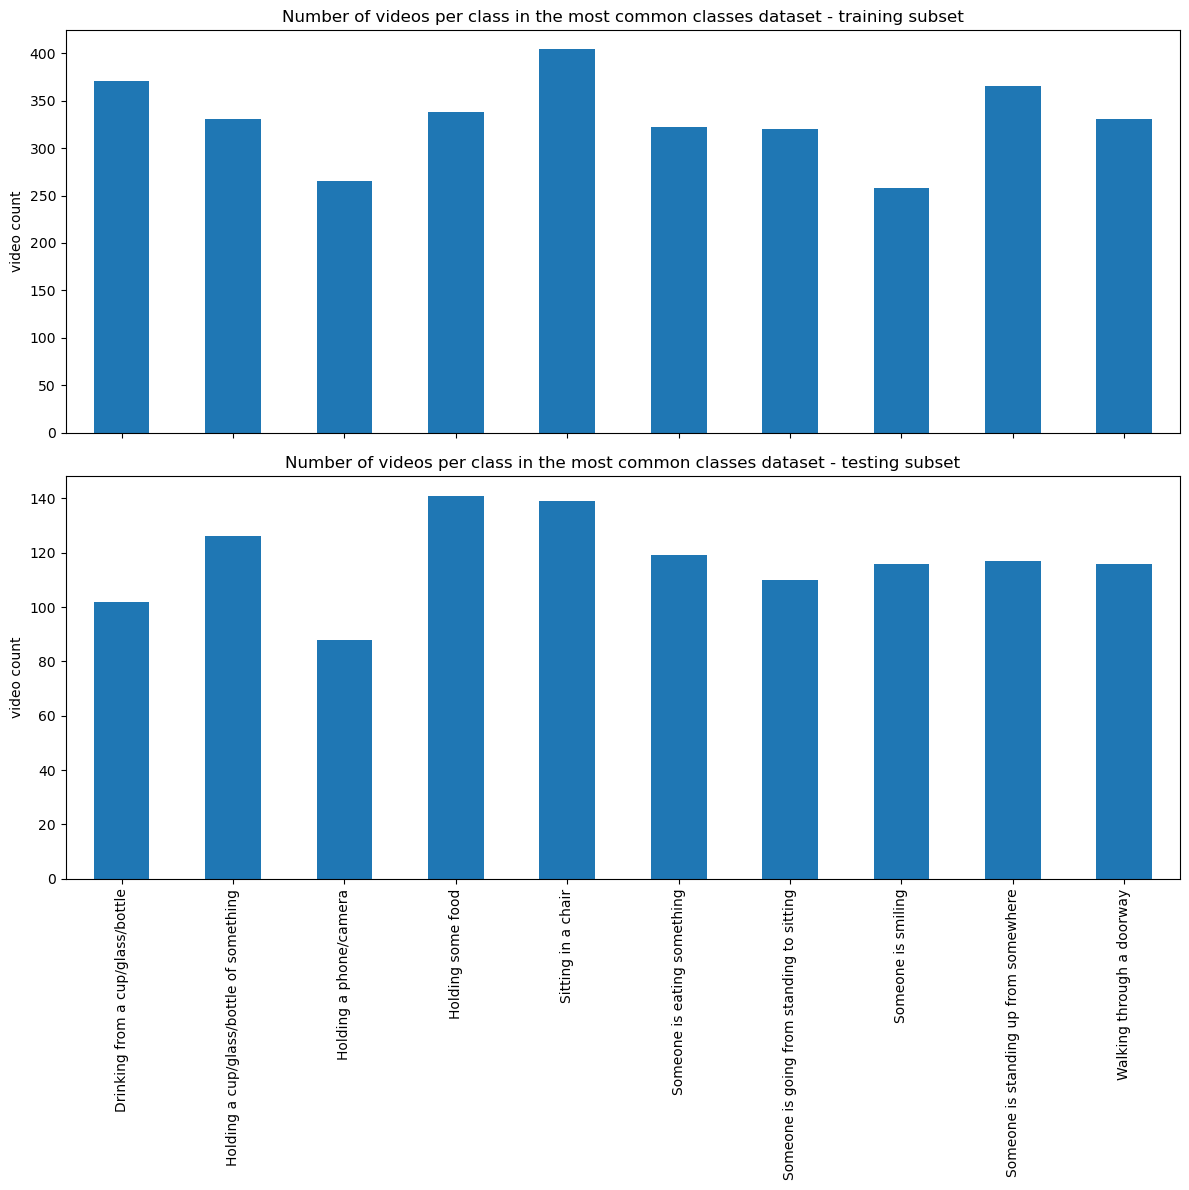

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

most_common_gt[most_common_gt["subset"] == "training"].groupby("label")[
    "video_id"
].nunique().plot(
    kind="bar",
    ax=ax[0],
    title="Number of videos per class in the most common classes dataset - training subset",
    xlabel="",
    ylabel="video count",
)

most_common_gt[most_common_gt["subset"] == "testing"].groupby("label")[
    "video_id"
].nunique().plot(
    kind="bar",
    ax=ax[1],
    title="Number of videos per class in the most common classes dataset - testing subset",
    xlabel="",
    ylabel="video count",
)

plt.tight_layout()
plt.show()

# Checking if the sample covers the population

In [17]:
most_common_gt.sample(5)

,video_id,duration,subset,start,end,label
48660,RZIAJ,30.21,training,1.8,13.8,Holding a phone/camera
44492,TEPWB,30.58,training,18.0,24.9,Drinking from a cup/glass/bottle
58059,ZAO65,26.75,training,7.3,14.1,Drinking from a cup/glass/bottle
42770,XKM5R,30.54,training,0.0,32.0,Holding a cup/glass/bottle of something
28009,EYZXC,41.17,testing,7.9,23.4,Holding a cup/glass/bottle of something


In [18]:
most_common_gt[most_common_gt['video_id'] == '6KDQO']

,video_id,duration,subset,start,end,label
17549,6KDQO,29.79,training,21.3,27.5,Someone is standing up from somewhere
17550,6KDQO,29.79,training,9.9,18.6,Drinking from a cup/glass/bottle
17552,6KDQO,29.79,training,4.9,10.5,Someone is going from standing to sitting
17553,6KDQO,29.79,training,6.7,24.4,Sitting in a chair
17555,6KDQO,29.79,training,2.2,28.0,Holding some food


In [19]:
gt_df[(gt_df['video_id'] == '6KDQO') & (gt_df['label'].isin(most_common_classes))]

,video_id,duration,subset,start,end,label
17549,6KDQO,29.79,training,21.3,27.5,Someone is standing up from somewhere
17550,6KDQO,29.79,training,9.9,18.6,Drinking from a cup/glass/bottle
17552,6KDQO,29.79,training,4.9,10.5,Someone is going from standing to sitting
17553,6KDQO,29.79,training,6.7,24.4,Sitting in a chair
17555,6KDQO,29.79,training,2.2,28.0,Holding some food
